# Paso 7: Baseline y Comparación (Risk Score Interpretable)

Este notebook NO entrena modelos de machine learning.
En su lugar, construimos un **risk score interpretable** basado en reglas y ponderaciones de features.

## Objetivos:

1. **Normalizar features clave** para ponerlas en misma escala
2. **Construir sub-scores** por familias de señales (monto, acceso, contexto, velocidad, entidad)
3. **Calcular risk_score** como suma ponderada de sub-scores
4. **Definir alertas** por percentiles (top 1%, top 5%)
5. **Generar rankings** de transacciones, cuentas, comercios y canales más sospechosos
6. **Visualizar** distribución de riesgo y componentes

## Limitación Importante:

El `risk_score` indica **comportamiento inusual o sospechoso**, NO fraude confirmado.
Es un proxy útil para priorizar revisiones manuales o alimentar modelos posteriores.

## Setup: Imports y Configuración

Cargamos librerías y configuramos estilo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Estilo seaborn
sns.set_style("whitegrid")
sns.set_palette("deep")

# Configuración de visualización
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


## Cargar Dataset Model-Ready

Cargamos el dataset con todas las features creadas en el paso anterior.

In [2]:
#%%
model_ready_path = 'outputs/tables/df_model_ready.csv'

if os.path.exists(model_ready_path):
    df = pd.read_csv(model_ready_path)
    print(f"✓ Dataset cargado desde {model_ready_path}")
else:
    # Buscar en otras ubicaciones si no existe
    print(f"⚠ No se encontró {model_ready_path}, buscando alternativas...")
    df = pd.read_csv('../outputs/tables/df_model_ready.csv')
    print("✓ Dataset cargado desde ruta alternativa")

print(f"\nShape: {df.shape}")
print(f"Columnas: {len(df.columns)}")

✓ Dataset cargado desde outputs/tables/df_model_ready.csv

Shape: (2512, 79)
Columnas: 79


## Verificar Columnas Clave

Confirmamos que todas las features necesarias para el risk score existen.

In [3]:
#%%
required_cols = [
    'amount_to_balance', 'amount_log', 'is_online', 'is_high_login', 
    'is_night', 'is_weekend', 'new_device_for_account', 'new_ip_for_account',
    'new_merchant_for_account', 'new_location_for_account',
    'tx_count_rolling_1d', 'amount_sum_daily'
]

optional_cols = [
    'acc_unique_ips', 'acc_unique_devices', 'acc_ratio_p95',
    'merch_amount_p95', 'chan_amount_p95', 'chan_login_attempts_mean'
]

# Verificar columnas requeridas
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    print(f"⚠ FALTAN columnas requeridas: {missing_required}")
else:
    print("✓ Todas las columnas requeridas están presentes")

# Verificar columnas opcionales
available_optional = [col for col in optional_cols if col in df.columns]
print(f"\n✓ Columnas opcionales disponibles: {available_optional}")

missing_optional = [col for col in optional_cols if col not in df.columns]
if missing_optional:
    print(f"⚠ Columnas opcionales faltantes: {missing_optional}")

✓ Todas las columnas requeridas están presentes

✓ Columnas opcionales disponibles: ['acc_unique_ips', 'acc_unique_devices', 'acc_ratio_p95', 'merch_amount_p95', 'chan_amount_p95', 'chan_login_attempts_mean']


## Crear Directorios de Salida

Aseguramos que existen las carpetas para guardar outputs.

In [4]:
#%%
Path('outputs/tables').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

print("✓ Directorios creados: outputs/tables/ y outputs/figures/")

✓ Directorios creados: outputs/tables/ y outputs/figures/


---
# A) Normalización de Features

## Clip Outliers (Percentil 99)

Para evitar que outliers extremos dominen el score, capamos features numéricas al percentil 99.

In [5]:
#%%
# amount_to_balance
p99_amount_to_balance = df['amount_to_balance'].quantile(0.99)
df['amount_to_balance_clip'] = df['amount_to_balance'].clip(upper=p99_amount_to_balance)

# tx_count_rolling_1d
p99_tx_count = df['tx_count_rolling_1d'].quantile(0.99)
df['tx_count_rolling_1d_clip'] = df['tx_count_rolling_1d'].clip(upper=p99_tx_count)

# amount_sum_daily
p99_amount_sum = df['amount_sum_daily'].quantile(0.99)
df['amount_sum_daily_clip'] = df['amount_sum_daily'].clip(upper=p99_amount_sum)

# amount_log (ya está relativamente normalizado, pero por consistencia)
p99_amount_log = df['amount_log'].quantile(0.99)
df['amount_log_clip'] = df['amount_log'].clip(upper=p99_amount_log)

print("✓ Features numéricas capadas al P99")
print(f"  amount_to_balance: P99 = {p99_amount_to_balance:.4f}")
print(f"  tx_count_rolling_1d: P99 = {p99_tx_count:.0f}")
print(f"  amount_sum_daily: P99 = ${p99_amount_sum:.2f}")
print(f"  amount_log: P99 = {p99_amount_log:.2f}")

✓ Features numéricas capadas al P99
  amount_to_balance: P99 = 2.2890
  tx_count_rolling_1d: P99 = 2
  amount_sum_daily: P99 = $1411.52
  amount_log: P99 = 7.22


## Clip Features de Entidad (Account)

Capamos features agregadas por cuenta si existen.

In [6]:
#%%
if 'acc_unique_ips' in df.columns:
    p99_unique_ips = df['acc_unique_ips'].quantile(0.99)
    df['acc_unique_ips_clip'] = df['acc_unique_ips'].clip(upper=p99_unique_ips)
    print(f"✓ acc_unique_ips capado: P99 = {p99_unique_ips:.0f}")
else:
    df['acc_unique_ips_clip'] = 0
    print("⚠ acc_unique_ips no disponible, usando 0")

if 'acc_unique_devices' in df.columns:
    p99_unique_devices = df['acc_unique_devices'].quantile(0.99)
    df['acc_unique_devices_clip'] = df['acc_unique_devices'].clip(upper=p99_unique_devices)
    print(f"✓ acc_unique_devices capado: P99 = {p99_unique_devices:.0f}")
else:
    df['acc_unique_devices_clip'] = 0
    print("⚠ acc_unique_devices no disponible, usando 0")

if 'acc_ratio_p95' in df.columns:
    p99_ratio_p95 = df['acc_ratio_p95'].quantile(0.99)
    df['acc_ratio_p95_clip'] = df['acc_ratio_p95'].clip(upper=p99_ratio_p95)
    print(f"✓ acc_ratio_p95 capado: P99 = {p99_ratio_p95:.4f}")
else:
    df['acc_ratio_p95_clip'] = 0
    print("⚠ acc_ratio_p95 no disponible, usando 0")

✓ acc_unique_ips capado: P99 = 12
✓ acc_unique_devices capado: P99 = 12
✓ acc_ratio_p95 capado: P99 = 3.7852


## Normalizar a [0,1] (Min-Max Scaling)

Escalamos cada feature capada a rango [0,1] para que todas contribuyan equitativamente antes de ponderar.

In [7]:
#%%
def minmax_scale(series):
    """Escala serie a [0,1] usando min-max"""
    min_val = series.min()
    max_val = series.max()
    if max_val - min_val == 0:
        return series * 0  # Si no hay variación, retornar 0
    return (series - min_val) / (max_val - min_val)

# Escalar features numéricas
df['amount_to_balance_scaled'] = minmax_scale(df['amount_to_balance_clip'])
df['amount_log_scaled'] = minmax_scale(df['amount_log_clip'])
df['tx_count_rolling_1d_scaled'] = minmax_scale(df['tx_count_rolling_1d_clip'])
df['amount_sum_daily_scaled'] = minmax_scale(df['amount_sum_daily_clip'])

# Escalar features de entidad
df['acc_unique_ips_scaled'] = minmax_scale(df['acc_unique_ips_clip'])
df['acc_unique_devices_scaled'] = minmax_scale(df['acc_unique_devices_clip'])
df['acc_ratio_p95_scaled'] = minmax_scale(df['acc_ratio_p95_clip'])

print("✓ Features normalizadas a [0,1]")
print("\nRangos de features escaladas:")
for col in ['amount_to_balance_scaled', 'tx_count_rolling_1d_scaled', 'acc_unique_ips_scaled']:
    print(f"  {col}: [{df[col].min():.3f}, {df[col].max():.3f}]")

✓ Features normalizadas a [0,1]

Rangos de features escaladas:
  amount_to_balance_scaled: [0.000, 1.000]
  tx_count_rolling_1d_scaled: [0.000, 1.000]
  acc_unique_ips_scaled: [0.000, 1.000]


---
# B) Construir Risk Score

## Definir Sub-Scores por Familia de Señales

Creamos puntuaciones parciales para cada tipo de comportamiento sospechoso.

In [8]:
#%%
# FAMILIA 1: Monto (alto ratio monto/saldo + montos altos)
# Pesos: ratio es más importante que monto absoluto
w1_ratio = 3.0
w2_amount = 1.0
df['score_amount'] = (
    w1_ratio * df['amount_to_balance_scaled'] + 
    w2_amount * df['amount_log_scaled']
)

print(f"✓ score_amount creado (rango: [{df['score_amount'].min():.2f}, {df['score_amount'].max():.2f}])")
print(f"  Media: {df['score_amount'].mean():.2f}")

✓ score_amount creado (rango: [0.00, 3.99])
  Media: 0.94


## Sub-Score: Señales de Acceso Anómalo

Combinamos múltiples intentos de login, dispositivos nuevos, IPs nuevas, comercios y ubicaciones nuevas.

In [ ]:
# FAMILIA 2: Acceso (login attempts + novedades)
# Pesos: new_ip y new_device son señales fuertes
w3_login = 2.0
w4_device = 3.0
w5_ip = 3.0
w6_merchant = 1.0
w7_location = 1.0

df['score_access'] = (
    w3_login * df['is_high_login'] +
    w4_device * df['new_device_for_account'] +
    w5_ip * df['new_ip_for_account'] +
    w6_merchant * df['new_merchant_for_account'] +
    w7_location * df['new_location_for_account']
)

print(f"✓ score_access creado (rango: [{df['score_access'].min():.2f}, {df['score_access'].max():.2f}])")
print(f"  Media: {df['score_access'].mean():.2f}")
print(f"  P95: {df['score_access'].quantile(0.95):.2f}")

✓ score_access creado (rango: [4.00, 10.00])
  Media: 7.94
  P95: 8.00


## Sub-Score: Contexto de Transacción

Canal online, horario nocturno y fin de semana (patrones de riesgo temporal/canal).

In [10]:
#%%
# FAMILIA 3: Contexto (online + night + weekend)
# Pesos: night es más sospechoso que online o weekend
w8_online = 1.0
w9_night = 2.0
w10_weekend = 0.5

df['score_context'] = (
    w8_online * df['is_online'] +
    w9_night * df['is_night'] +
    w10_weekend * df['is_weekend']
)

print(f"✓ score_context creado (rango: [{df['score_context'].min():.2f}, {df['score_context'].max():.2f}])")
print(f"  Media: {df['score_context'].mean():.2f}")

✓ score_context creado (rango: [0.00, 1.00])
  Media: 0.32


## Sub-Score: Velocidad (Actividad Reciente)

Múltiples transacciones en corto tiempo y alto volumen diario.

In [11]:
#%%
# FAMILIA 4: Velocidad (actividad diaria)
# Pesos: número de transacciones y monto acumulado
w11_tx_count = 2.0
w12_amount_sum = 1.5

df['score_velocity'] = (
    w11_tx_count * df['tx_count_rolling_1d_scaled'] +
    w12_amount_sum * df['amount_sum_daily_scaled']
)

print(f"✓ score_velocity creado (rango: [{df['score_velocity'].min():.2f}, {df['score_velocity'].max():.2f}])")
print(f"  Media: {df['score_velocity'].mean():.2f}")

✓ score_velocity creado (rango: [0.00, 3.50])
  Media: 0.38


## Sub-Score: Perfil de Entidad (Cuenta)

Cuentas con historial de alta diversidad de IPs/dispositivos y ratios altos.

In [12]:
#%%
# FAMILIA 5: Entidad (historial de cuenta)
# Pesos: IPs y devices únicos son señales importantes
w13_unique_ips = 2.5
w14_unique_devices = 2.0
w15_ratio_p95 = 1.5

df['score_entity'] = (
    w13_unique_ips * df['acc_unique_ips_scaled'] +
    w14_unique_devices * df['acc_unique_devices_scaled'] +
    w15_ratio_p95 * df['acc_ratio_p95_scaled']
)

print(f"✓ score_entity creado (rango: [{df['score_entity'].min():.2f}, {df['score_entity'].max():.2f}])")
print(f"  Media: {df['score_entity'].mean():.2f}")

✓ score_entity creado (rango: [0.00, 5.66])
  Media: 2.33


## Calcular Risk Score Total

Sumamos todos los sub-scores para obtener el puntaje de riesgo final.

In [13]:
#%%
df['risk_score'] = (
    df['score_amount'] +
    df['score_access'] +
    df['score_context'] +
    df['score_velocity'] +
    df['score_entity']
)

print(f"✓ risk_score calculado")
print(f"\nEstadísticas de risk_score:")
print(df['risk_score'].describe())
print(f"\nPercentiles clave:")
print(f"  P90: {df['risk_score'].quantile(0.90):.2f}")
print(f"  P95: {df['risk_score'].quantile(0.95):.2f}")
print(f"  P99: {df['risk_score'].quantile(0.99):.2f}")

✓ risk_score calculado

Estadísticas de risk_score:
count    2512.000000
mean       11.912204
std         1.614891
min         6.784696
25%        10.801385
50%        11.697373
75%        12.831084
max        20.042740
Name: risk_score, dtype: float64

Percentiles clave:
  P90: 13.97
  P95: 14.85
  P99: 16.69


## Generar risk_reason (Explicación Cualitativa)

Creamos una columna de texto que explica qué flags se activaron para cada transacción.

In [14]:
#%%
def generate_risk_reason(row):
    """Genera texto explicativo de señales de riesgo activadas"""
    reasons = []
    
    # Señales binarias
    if row['is_high_login'] == 1:
        reasons.append('high_login')
    if row['new_device_for_account'] == 1:
        reasons.append('new_device')
    if row['new_ip_for_account'] == 1:
        reasons.append('new_ip')
    if row['new_merchant_for_account'] == 1:
        reasons.append('new_merchant')
    if row['new_location_for_account'] == 1:
        reasons.append('new_location')
    if row['is_online'] == 1:
        reasons.append('online')
    if row['is_night'] == 1:
        reasons.append('night')
    if row['is_weekend'] == 1:
        reasons.append('weekend')
    
    # Señales continuas (valores altos)
    if row['amount_to_balance_scaled'] > 0.7:
        reasons.append('high_ratio')
    if row['tx_count_rolling_1d_scaled'] > 0.7:
        reasons.append('high_velocity')
    if row['acc_unique_ips_scaled'] > 0.7:
        reasons.append('many_ips')
    if row['acc_unique_devices_scaled'] > 0.7:
        reasons.append('many_devices')
    
    return ' + '.join(reasons) if reasons else 'no_flags'

df['risk_reason'] = df.apply(generate_risk_reason, axis=1)

print("✓ risk_reason generado")
print(f"\nEjemplos de risk_reason:")
print(df[df['risk_score'] > df['risk_score'].quantile(0.95)]['risk_reason'].head(10).tolist())

✓ risk_reason generado

Ejemplos de risk_reason:
['new_device + new_ip + new_merchant + new_location + high_velocity + many_ips + many_devices', 'new_device + new_ip + new_merchant + new_location + high_velocity + many_ips + many_devices', 'new_device + new_ip + new_merchant + new_location + online', 'new_device + new_ip + new_merchant + new_location + high_velocity', 'new_device + new_ip + new_merchant + new_location + high_velocity', 'new_device + new_ip + new_merchant + new_location + online + high_ratio', 'new_device + new_ip + new_merchant + new_location + many_ips + many_devices', 'new_device + new_ip + new_merchant + new_location + online + high_ratio + many_ips + many_devices', 'new_device + new_ip + new_merchant + new_location + high_velocity + many_ips + many_devices', 'new_device + new_ip + new_merchant + high_ratio + high_velocity + many_ips + many_devices']


---
# C) Definir Alertas por Percentil

## Crear Flags de Alerta (Top 1% y Top 5%)

Definimos niveles de alerta basados en percentiles de risk_score.

In [15]:
#%%
# Umbrales
threshold_p99 = df['risk_score'].quantile(0.99)
threshold_p95 = df['risk_score'].quantile(0.95)

# Flags de alerta
df['alert_top_1'] = (df['risk_score'] >= threshold_p99).astype(int)
df['alert_top_5'] = (df['risk_score'] >= threshold_p95).astype(int)

# Reportar
n_total = len(df)
n_top1 = df['alert_top_1'].sum()
n_top5 = df['alert_top_5'].sum()

print(f"✓ Alertas definidas")
print(f"\nUmbrales:")
print(f"  Top 1% (P99): risk_score >= {threshold_p99:.2f}")
print(f"  Top 5% (P95): risk_score >= {threshold_p95:.2f}")
print(f"\nDistribución de alertas:")
print(f"  alert_top_1: {n_top1} transacciones ({n_top1/n_total*100:.2f}%)")
print(f"  alert_top_5: {n_top5} transacciones ({n_top5/n_total*100:.2f}%)")

✓ Alertas definidas

Umbrales:
  Top 1% (P99): risk_score >= 16.69
  Top 5% (P95): risk_score >= 14.85

Distribución de alertas:
  alert_top_1: 26 transacciones (1.04%)
  alert_top_5: 126 transacciones (5.02%)


---
# D) Visualizaciones

## Histograma + KDE: Distribución de Risk Score

Visualizamos la distribución completa del risk_score con líneas de percentiles clave.

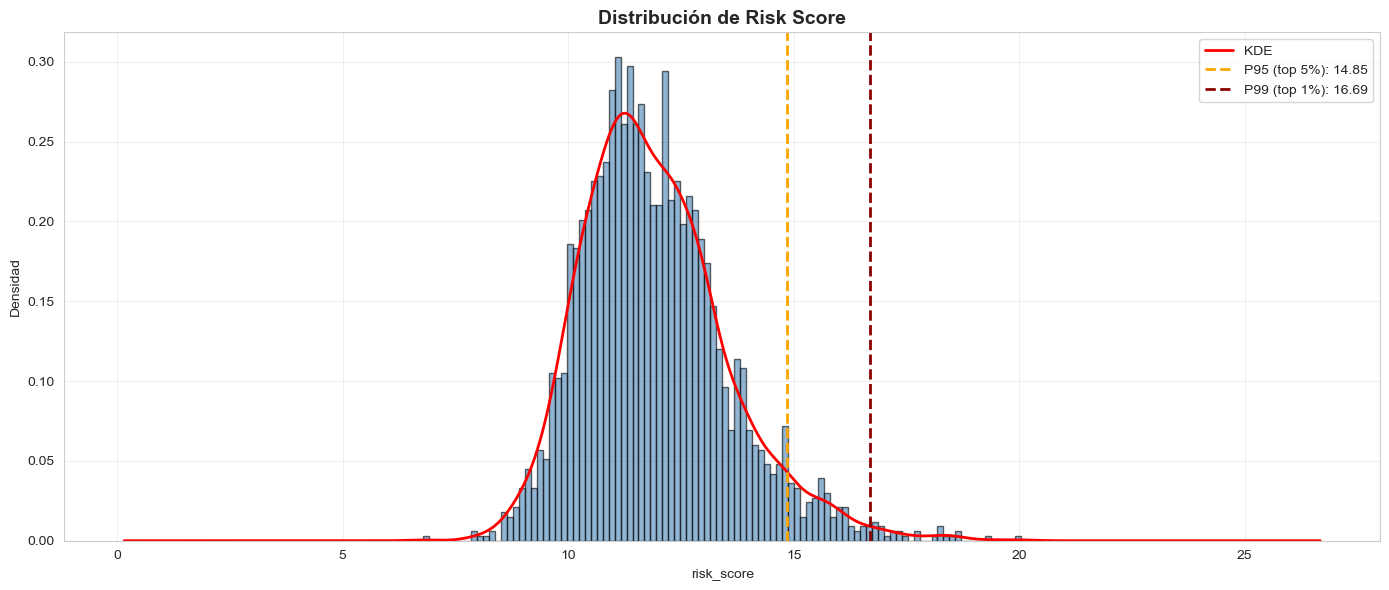

In [16]:
#%%
fig, ax = plt.subplots(figsize=(14, 6))

# Histograma
ax.hist(df['risk_score'], bins=100, alpha=0.6, color='steelblue', edgecolor='black', density=True)

# KDE
df['risk_score'].plot(kind='kde', ax=ax, color='red', linewidth=2, label='KDE')

# Líneas de percentiles
ax.axvline(threshold_p95, color='orange', linestyle='--', linewidth=2, label=f'P95 (top 5%): {threshold_p95:.2f}')
ax.axvline(threshold_p99, color='darkred', linestyle='--', linewidth=2, label=f'P99 (top 1%): {threshold_p99:.2f}')

ax.set_title('Distribución de Risk Score', fontsize=14, fontweight='bold')
ax.set_xlabel('risk_score')
ax.set_ylabel('Densidad')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/risk_score_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## Barplot: Porcentaje de Alertas Top 5% por Canal

Comparamos qué canales tienen mayor proporción de transacciones de alto riesgo.

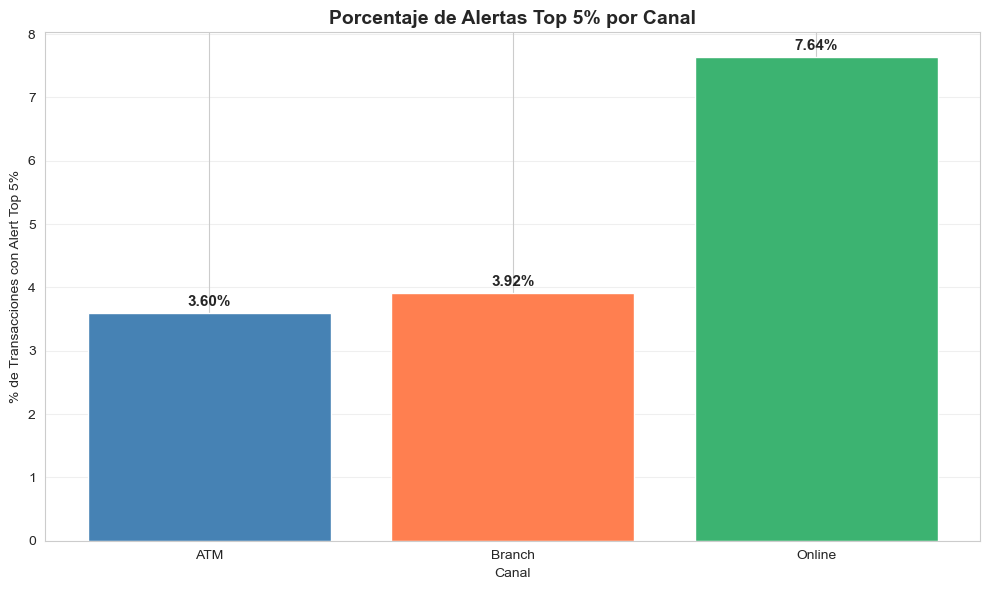


Alertas por canal:
  Channel  total_tx  alert_count  alert_pct
0     ATM       833           30   3.601441
1  Branch       868           34   3.917051
2  Online       811           62   7.644883


In [17]:
#%%
fig, ax = plt.subplots(figsize=(10, 6))

# Calcular porcentaje de alertas por canal
alert_by_channel = df.groupby('Channel').agg(
    total_tx=('TransactionID', 'count'),
    alert_count=('alert_top_5', 'sum')
).reset_index()
alert_by_channel['alert_pct'] = alert_by_channel['alert_count'] / alert_by_channel['total_tx'] * 100

# Barplot
ax.bar(alert_by_channel['Channel'], alert_by_channel['alert_pct'], 
       color=['steelblue', 'coral', 'mediumseagreen'])
ax.set_title('Porcentaje de Alertas Top 5% por Canal', fontsize=14, fontweight='bold')
ax.set_xlabel('Canal')
ax.set_ylabel('% de Transacciones con Alert Top 5%')
ax.grid(True, alpha=0.3, axis='y')

# Agregar valores sobre las barras
for i, (channel, pct) in enumerate(zip(alert_by_channel['Channel'], alert_by_channel['alert_pct'])):
    ax.text(i, pct + 0.1, f'{pct:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/alerts_by_channel.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nAlertas por canal:")
print(alert_by_channel)

## Barplot: Contribución Promedio de Cada Sub-Score

Mostramos qué familias de señales contribuyen más al risk_score en promedio.

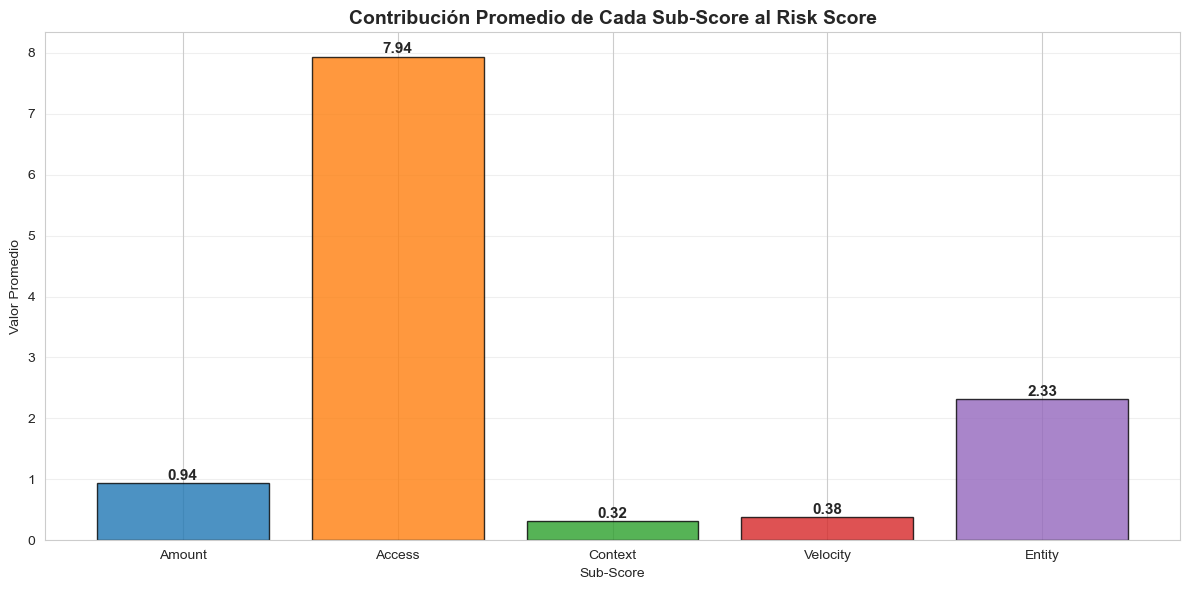


Contribución promedio de sub-scores:
  Amount: 0.94
  Access: 7.94
  Context: 0.32
  Velocity: 0.38
  Entity: 2.33


In [18]:
#%%
fig, ax = plt.subplots(figsize=(12, 6))

# Calcular promedios de sub-scores
subscores = ['score_amount', 'score_access', 'score_context', 'score_velocity', 'score_entity']
means = [df[col].mean() for col in subscores]
labels = ['Amount', 'Access', 'Context', 'Velocity', 'Entity']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ax.bar(labels, means, color=colors, alpha=0.8, edgecolor='black')
ax.set_title('Contribución Promedio de Cada Sub-Score al Risk Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Sub-Score')
ax.set_ylabel('Valor Promedio')
ax.grid(True, alpha=0.3, axis='y')

# Agregar valores
for i, (label, mean) in enumerate(zip(labels, means)):
    ax.text(i, mean + 0.05, f'{mean:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/subscore_contributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nContribución promedio de sub-scores:")
for label, mean in zip(labels, means):
    print(f"  {label}: {mean:.2f}")

## Boxplot: Risk Score por Canal

Comparamos la distribución del risk_score entre canales.

C:\Users\joako\AppData\Local\Temp\ipykernel_18788\1638375480.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Channel', y='risk_score', ax=ax, palette='Set2')


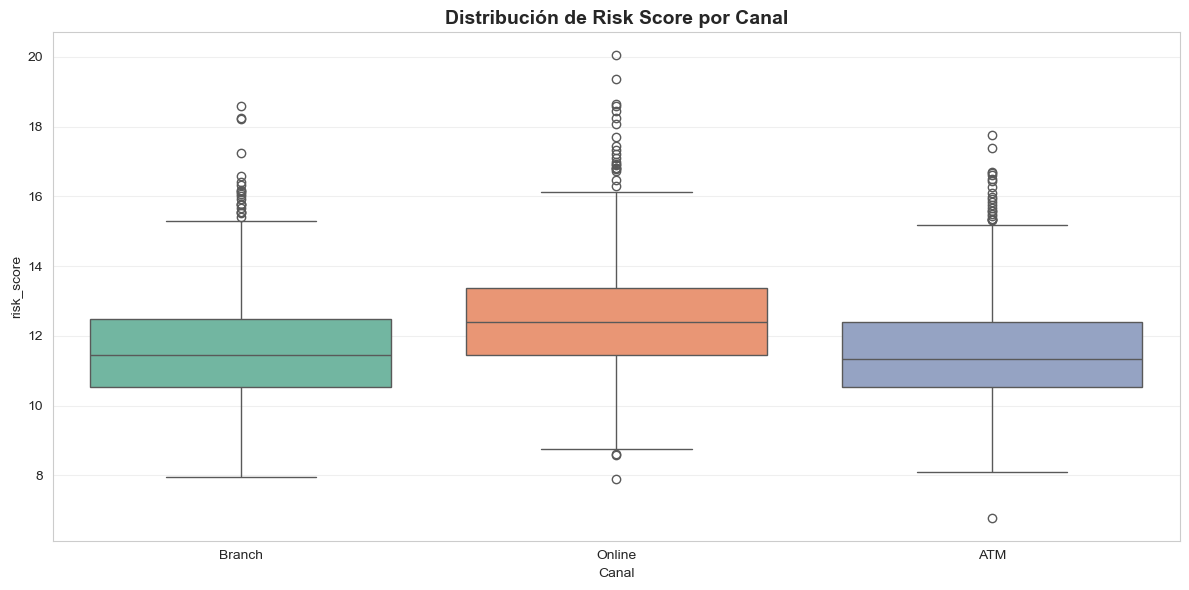

In [19]:
#%%
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df, x='Channel', y='risk_score', ax=ax, palette='Set2')
ax.set_title('Distribución de Risk Score por Canal', fontsize=14, fontweight='bold')
ax.set_xlabel('Canal')
ax.set_ylabel('risk_score')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/risk_score_by_channel.png', dpi=100, bbox_inches='tight')
plt.show()

## Scatter: Risk Score vs TransactionAmount

Relación entre riesgo calculado y monto de transacción (coloreado por alertas).

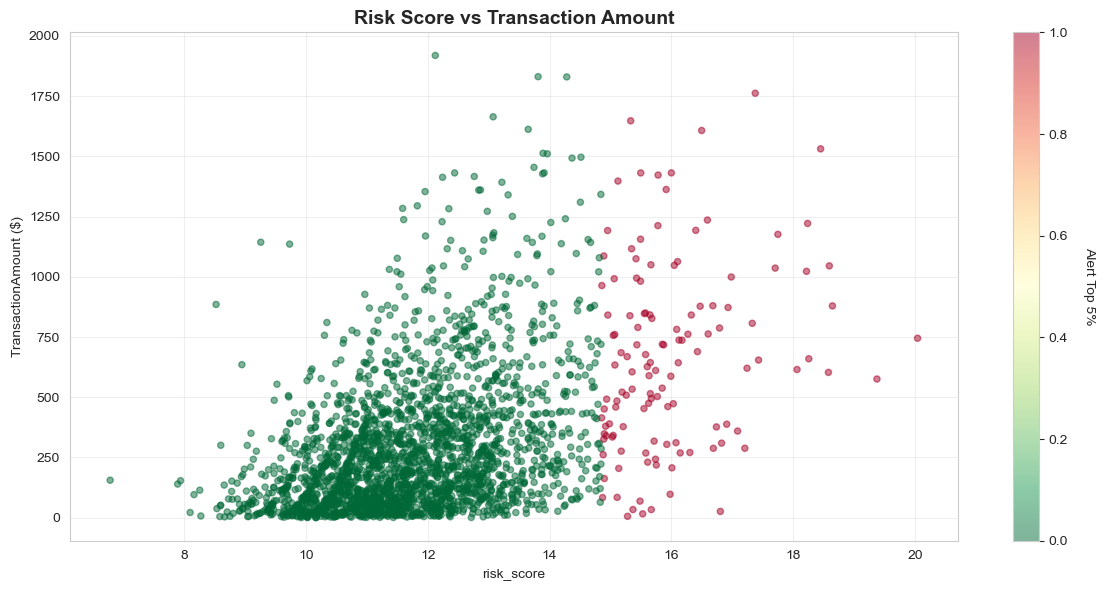

In [20]:
#%%
fig, ax = plt.subplots(figsize=(12, 6))

# Muestra aleatoria para mejor visualización
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

scatter = ax.scatter(
    sample_df['risk_score'], 
    sample_df['TransactionAmount'],
    c=sample_df['alert_top_5'],
    cmap='RdYlGn_r',
    alpha=0.5,
    s=20
)

ax.set_title('Risk Score vs Transaction Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('risk_score')
ax.set_ylabel('TransactionAmount ($)')
ax.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Alert Top 5%', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig('outputs/figures/risk_score_vs_amount.png', dpi=100, bbox_inches='tight')
plt.show()

---
# E) Rankings y Exportación

## Ranking 1: Top 50 Transacciones por Risk Score

Las transacciones individuales más sospechosas.

In [21]:
#%%
# Columnas relevantes para el ranking
ranking_cols = [
    'TransactionID', 'AccountID', 'MerchantID', 'Channel',
    'TransactionAmount', 'AccountBalance', 'risk_score', 'risk_reason',
    'alert_top_1', 'alert_top_5'
]

# Filtrar columnas que existen
ranking_cols_exist = [col for col in ranking_cols if col in df.columns]

# Top 50
top_transactions = df.nlargest(50, 'risk_score')[ranking_cols_exist]

# Guardar
top_transactions.to_csv('outputs/tables/ranking_top_transacciones.csv', index=False)

print(f"✓ Ranking top transacciones guardado: outputs/tables/ranking_top_transacciones.csv")
print(f"  Total: {len(top_transactions)} transacciones")
print(f"\nPrimeras 5 transacciones más riesgosas:")
print(top_transactions[['TransactionID', 'AccountID', 'risk_score', 'risk_reason']].head())

✓ Ranking top transacciones guardado: outputs/tables/ranking_top_transacciones.csv
  Total: 50 transacciones

Primeras 5 transacciones más riesgosas:
     TransactionID AccountID  risk_score                                        risk_reason
2480      TX000451   AC00495   20.042740  new_device + new_ip + new_merchant + new_locat...
1414      TX001040   AC00284   19.375309  new_device + new_ip + new_merchant + new_locat...
670       TX002192   AC00131   18.644543  new_device + new_ip + new_merchant + new_locat...
1663      TX001078   AC00331   18.593766  new_device + new_ip + new_merchant + new_locat...
111       TX001259   AC00020   18.578851  new_device + new_ip + new_merchant + high_rati...


## Ranking 2: Top Cuentas por Alertas y Risk Score

Cuentas con mayor número de alertas y mayor risk_score promedio.

In [22]:
#%%
# Agregación por cuenta
ranking_accounts = df.groupby('AccountID').agg(
    tx_count=('TransactionID', 'count'),
    max_risk=('risk_score', 'max'),
    mean_risk=('risk_score', 'mean'),
    n_alerts_top_5=('alert_top_5', 'sum'),
    n_alerts_top_1=('alert_top_1', 'sum'),
    total_amount=('TransactionAmount', 'sum')
).reset_index()

# Ordenar por alertas y max_risk
ranking_accounts = ranking_accounts.sort_values(['n_alerts_top_5', 'max_risk'], ascending=False)

# Guardar
ranking_accounts.to_csv('outputs/tables/ranking_top_cuentas.csv', index=False)

print(f"✓ Ranking top cuentas guardado: outputs/tables/ranking_top_cuentas.csv")
print(f"  Total cuentas: {len(ranking_accounts)}")
print(f"\nTop 10 cuentas más riesgosas:")
print(ranking_accounts.head(10))

✓ Ranking top cuentas guardado: outputs/tables/ranking_top_cuentas.csv
  Total cuentas: 495

Top 10 cuentas más riesgosas:
    AccountID  tx_count   max_risk  mean_risk  n_alerts_top_5  n_alerts_top_1  total_amount
455   AC00460        12  18.256468  15.156222               6               2       5570.34
19    AC00020         9  18.578851  15.379196               4               3       3788.01
451   AC00456        11  18.218594  14.623315               4               1       3090.60
253   AC00257        11  17.242536  14.428303               4               1       3410.02
333   AC00337         8  16.824482  14.806971               4               1       4393.41
357   AC00362        12  16.739670  14.632383               4               1       2991.32
489   AC00495         8  20.042740  14.795458               3               1       2405.77
280   AC00284         8  19.375309  14.832843               3               2       3533.35
175   AC00177         9  16.174757  14.465629    

## Ranking 3: Top Comercios por Alertas y Risk Score

Comercios con mayor actividad sospechosa.

In [23]:
#%%
# Agregación por comercio
ranking_merchants = df.groupby('MerchantID').agg(
    tx_count=('TransactionID', 'count'),
    max_risk=('risk_score', 'max'),
    mean_risk=('risk_score', 'mean'),
    n_alerts_top_5=('alert_top_5', 'sum'),
    n_alerts_top_1=('alert_top_1', 'sum'),
    unique_accounts=('AccountID', 'nunique')
).reset_index()

# Ordenar
ranking_merchants = ranking_merchants.sort_values(['n_alerts_top_5', 'max_risk'], ascending=False)

# Guardar
ranking_merchants.to_csv('outputs/tables/ranking_top_comercios.csv', index=False)

print(f"✓ Ranking top comercios guardado: outputs/tables/ranking_top_comercios.csv")
print(f"  Total comercios: {len(ranking_merchants)}")
print(f"\nTop 10 comercios más riesgosos:")
print(ranking_merchants.head(10))

✓ Ranking top comercios guardado: outputs/tables/ranking_top_comercios.csv
  Total comercios: 100

Top 10 comercios más riesgosos:
   MerchantID  tx_count   max_risk  mean_risk  n_alerts_top_5  n_alerts_top_1  unique_accounts
66       M067        25  17.704619  12.341995               4               2               25
19       M020        22  16.327481  12.560159               4               0               22
37       M038        31  16.303772  12.777432               4               0               30
36       M037        23  16.174757  12.028366               4               0               23
74       M075        19  20.042740  12.771004               3               1               19
35       M036        25  18.593766  12.744812               3               1               23
51       M052        27  18.256468  12.504291               3               1               26
93       M094        27  16.824482  12.251895               3               1               25
6        M007 

## Ranking 4: Canales por Risk Score y Alertas

Comparación de riesgo entre canales.

In [24]:
#%%
# Agregación por canal
ranking_channels = df.groupby('Channel').agg(
    tx_count=('TransactionID', 'count'),
    max_risk=('risk_score', 'max'),
    mean_risk=('risk_score', 'mean'),
    median_risk=('risk_score', 'median'),
    n_alerts_top_5=('alert_top_5', 'sum'),
    n_alerts_top_1=('alert_top_1', 'sum')
).reset_index()

# Calcular porcentajes
ranking_channels['pct_alert_top_5'] = ranking_channels['n_alerts_top_5'] / ranking_channels['tx_count'] * 100

# Ordenar
ranking_channels = ranking_channels.sort_values('mean_risk', ascending=False)

# Guardar
ranking_channels.to_csv('outputs/tables/ranking_canales.csv', index=False)

print(f"✓ Ranking canales guardado: outputs/tables/ranking_canales.csv")
print(f"\nRanking de canales por riesgo:")
print(ranking_channels)

✓ Ranking canales guardado: outputs/tables/ranking_canales.csv

Ranking de canales por riesgo:
  Channel  tx_count   max_risk  mean_risk  median_risk  n_alerts_top_5  n_alerts_top_1  pct_alert_top_5
2  Online       811  20.042740  12.565318    12.402520              62              19         7.644883
1  Branch       868  18.578851  11.627375    11.459050              34               4         3.917051
0     ATM       833  17.748785  11.573134    11.335852              30               3         3.601441


## Guardar Dataset Completo con Score

Exportamos el DataFrame completo con todas las columnas de scoring para uso posterior.

In [25]:
#%%
output_path = 'outputs/tables/df_scored.csv'
df.to_csv(output_path, index=False)

print(f"✓ Dataset con scores guardado en: {output_path}")
print(f"  Shape: {df.shape}")
print(f"  Tamaño: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")
print(f"\nColumnas clave del score:")
score_cols = [col for col in df.columns if 'score' in col or 'alert' in col or 'risk' in col]
print(f"  {score_cols}")

✓ Dataset con scores guardado en: outputs/tables/df_scored.csv
  Shape: (2512, 102)
  Tamaño: 2.36 MB

Columnas clave del score:
  ['score_amount', 'score_access', 'score_context', 'score_velocity', 'score_entity', 'risk_score', 'risk_reason', 'alert_top_1', 'alert_top_5']


---
# Resumen: Interpretación del Risk Score

## Componentes del Risk Score:

### 1. **score_amount** (Peso: 4 puntos máximo)
- **Qué mide**: Transacciones con ratio monto/saldo alto + montos absolutos altos
- **Por qué importa**: Transacciones que exceden la capacidad normal del saldo pueden indicar fraude o lavado
- **Peso mayor**: `amount_to_balance` (3x) vs `amount_log` (1x)

### 2. **score_access** (Peso: 10 puntos máximo)
- **Qué mide**: Múltiples intentos de login + uso de dispositivos/IPs/comercios/ubicaciones nuevas
- **Por qué importa**: Señales de compromiso de cuenta o comportamiento anómalo de acceso
- **Pesos mayores**: `new_ip` (3x) y `new_device` (3x) son las señales más fuertes

### 3. **score_context** (Peso: 3.5 puntos máximo)
- **Qué mide**: Canal online + horario nocturno + fin de semana
- **Por qué importa**: Patrones temporales asociados con mayor riesgo
- **Peso mayor**: `is_night` (2x) es más sospechoso que online o weekend

### 4. **score_velocity** (Peso: 3.5 puntos máximo)
- **Qué mide**: Alta frecuencia de transacciones y volumen diario elevado
- **Por qué importa**: Actividad inusualmente alta puede indicar uso indebido
- **Pesos**: `tx_count_rolling_1d` (2x) y `amount_sum_daily` (1.5x)

### 5. **score_entity** (Peso: 6 puntos máximo)
- **Qué mide**: Perfil histórico de la cuenta (diversidad de IPs/dispositivos, ratios altos)
- **Por qué importa**: Cuentas con historial de comportamiento errático son más sospechosas
- **Pesos mayores**: `unique_ips` (2.5x) y `unique_devices` (2x)

## Cómo Leer el Risk Score:

- **risk_score < P90**: Comportamiento normal o bajo riesgo
- **P90 ≤ risk_score < P95**: Riesgo moderado, monitorear
- **P95 ≤ risk_score < P99**: Alto riesgo, revisar manualmente (alert_top_5)
- **risk_score ≥ P99**: Riesgo crítico, investigar inmediatamente (alert_top_1)

## Cómo Usar los Rankings:

1. **ranking_top_transacciones.csv**: Lista las 50 transacciones más sospechosas con sus razones
2. **ranking_top_cuentas.csv**: Cuentas con más alertas (posibles cuentas comprometidas o fraudulentas)
3. **ranking_top_comercios.csv**: Comercios que concentran actividad sospechosa (posibles "mulas")
4. **ranking_canales.csv**: Comparación de riesgo por canal (para políticas diferenciadas)

## Limitaciones y Advertencias:

- **NO es detección de fraude confirmado**: El score indica "sospecha" basada en patrones, no certeza
- **Falsos positivos esperados**: Comportamiento legítimo pero inusual también generará scores altos
- **Complementar con investigación manual**: Los rankings son punto de partida, no decisión final
- **Ajustar pesos según negocio**: Los pesos actuales son una propuesta inicial, deben calibrarse con casos reales
- **Re-entrenar periódicamente**: Patrones de fraude evolucionan, el score debe actualizarse